In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

In [2]:
data = load_iris(as_frame=True)

df = data.frame.copy()
df["species"] = df["target"].map(dict(enumerate(data.target_names)))
df = df.drop(columns="target")

print(df.shape)
df.head()

(150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


,count
species,
setosa,50
versicolor,50
virginica,50


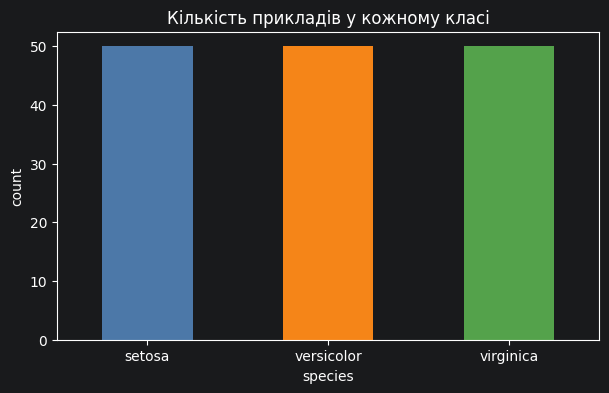

In [3]:

display(df.describe().T)

class_counts = df["species"].value_counts().sort_index()
display(class_counts.to_frame("count"))

fig, ax = plt.subplots(figsize=(7, 4))
class_counts.plot(kind="bar", ax=ax, color=["#4C78A8", "#F58518", "#54A24B"])
ax.set_title("Кількість прикладів у кожному класі")
ax.set_xlabel("species")
ax.set_ylabel("count")
plt.xticks(rotation=0)
plt.show()

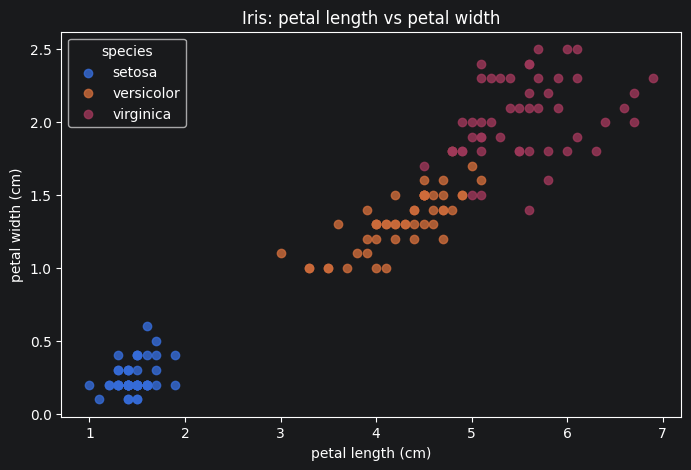

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for species, part in df.groupby("species"):
    ax.scatter(part["petal length (cm)"], part["petal width (cm)"], alpha=0.8, label=species)

ax.set_title("Iris: petal length vs petal width")
ax.set_xlabel("petal length (cm)")
ax.set_ylabel("petal width (cm)")
ax.legend(title="species")
plt.show()

In [5]:
X = df.drop(columns="species")
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Test class counts:")
print(y_test.value_counts().sort_index())

X_train: (105, 4)
X_test: (45, 4)
Test class counts:
species
setosa        15
versicolor    15
virginica     15
Name: count, dtype: int64


In [6]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","[np.str_('setosa'),np.str_('versicolor'),np.str_('virginica')]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['sepal length (cm)','sepal width (cm)','petal length (cm)', 'petal width (cm)']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [7]:
y_pred = model.predict(X_test)

metrics = pd.DataFrame([
    {"metric": "accuracy", "value": accuracy_score(y_test, y_pred)},
    {"metric": "precision_macro", "value": precision_score(y_test, y_pred, average="macro")},
    {"metric": "recall_macro", "value": recall_score(y_test, y_pred, average="macro")},
    {"metric": "f1_macro", "value": f1_score(y_test, y_pred, average="macro")},
])

metrics.round(3)

,metric,value
0,accuracy,0.911
1,precision_macro,0.916
2,recall_macro,0.911
3,f1_macro,0.911


[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]


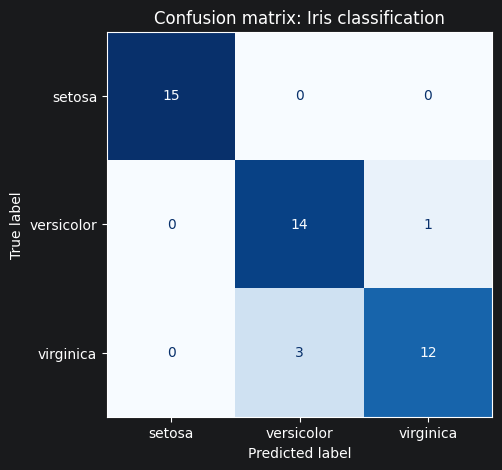

In [8]:
labels = list(data.target_names)
cm = confusion_matrix(y_test, y_pred, labels=labels)

print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
display_cm.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix: Iris classification")
plt.show()

In [9]:
print(classification_report(y_test, y_pred, labels=labels))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



In [10]:
proba = model.predict_proba(X_test)
proba_df = pd.DataFrame(proba, columns=model.classes_)
proba_df["true_class"] = y_test.reset_index(drop=True)
proba_df["predicted_class"] = y_pred
proba_df.head(10).round(3)

,setosa,versicolor,virginica,true_class,predicted_class
0,0.000,0.101,0.899,virginica,virginica
1,0.014,0.789,0.196,versicolor,versicolor
2,0.004,0.620,0.376,virginica,versicolor
3,0.022,0.629,0.349,versicolor,versicolor
4,0.005,0.385,0.610,virginica,virginica
5,0.000,0.022,0.978,virginica,virginica
6,0.016,0.915,0.070,versicolor,versicolor
7,0.034,0.939,0.028,versicolor,versicolor
8,0.938,0.062,0.000,setosa,setosa
9,0.000,0.055,0.945,virginica,virginica
